<img src="https://github.com/hernancontigiani/ceia_memorias_especializacion/raw/master/Figures/logoFIUBA.jpg" width="500" align="center">


# Procesamiento de lenguaje natural
## Modelo de lenguaje con tokenización por caracteres

#### Alumno: Martin Madrid
#### N° siu: a2409

### Consigna
- Seleccionar un corpus de texto sobre el cual entrenar el modelo de lenguaje.
- Realizar el pre-procesamiento adecuado para tokenizar el corpus, estructurar el dataset y separar entre datos de entrenamiento y validación.
- Proponer arquitecturas de redes neuronales basadas en unidades recurrentes para implementar un modelo de lenguaje.
- Con el o los modelos que consideren adecuados, generar nuevas secuencias a partir de secuencias de contexto con las estrategias de greedy search y beam search determístico y estocástico. En este último caso observar el efecto de la temperatura en la generación de secuencias.


### Sugerencias
- Durante el entrenamiento, guiarse por el descenso de la perplejidad en los datos de validación para finalizar el entrenamiento. Para ello se provee un callback.
- Explorar utilizar SimpleRNN (celda de Elman), LSTM y GRU.
- rmsprop es el optimizador recomendado para la buena convergencia. No obstante se pueden explorar otros.


In [101]:
import random
import re
import pickle
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from tensorflow import keras
from tensorflow.keras import layers
from keras.utils import to_categorical
from keras.models import Sequential
from keras.layers import Dense, LSTM, GRU, SimpleRNN, Embedding, Dropout
from tensorflow.keras.losses import SparseCategoricalCrossentropy
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.utils import pad_sequences

pd.set_option("display.max_colwidth", None)
pd.set_option("display.width", None)

SEED = 1313
random.seed(SEED)
np.random.seed(SEED)
keras.utils.set_random_seed(SEED)


In [73]:
from google.colab import drive
from pathlib import Path
import shutil

# Montar Google Drive
drive.mount("/content/drive")

# Ajustá esta ruta a donde tengas odisea.txt en tu Drive
origen = Path("/content/drive/MyDrive/NLP/tp3/odisea.txt")

# Destino en la VM de Colab
destino = Path("/content/odisea.txt")

if not origen.exists():
    print(f"No encontré el archivo en Drive: {origen}")
    print("\nBuscando odisea.txt en Drive...")
    !find /content/drive/MyDrive -iname "odisea.txt"
else:
    shutil.copy(origen, destino)
    print(f"Copiado a: {destino}")
    !ls -lh /content/odisea.txt

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Copiado a: /content/odisea.txt
-rw------- 1 root root 1.1M Jun 10 22:50 /content/odisea.txt


### Datos
Utilizaremos como dataset la Odisea de Homero, como en el tp2.

In [74]:
from pathlib import Path
import re

data_path = Path("/content/odisea.txt")  # ajustar si quedó en otra carpeta

raw_text = data_path.read_text(encoding="utf-8")
# Nos quedamos con el cuerpo de la obra, no con el prólogo/notas iniciales.
inicio = raw_text.find("CANTO PRIMERO")
if inicio != -1:
    raw_text = raw_text[inicio:]

# Usamos solo la primera mitad del cuerpo de la obra.
text = raw_text[:len(raw_text) // 2].lower()

# Quitamos texto griego y griego extendido.
text = re.sub(r"[\u0370-\u03ff\u1f00-\u1fff]+", " ", text)

# Quitamos referencias editoriales tipo [1], [14], etc.
text = re.sub(r"\[[^\]]*\]", " ", text)

# Quitamos marcas editoriales simples.
text = text.replace("_", " ")

# Quitamos números sueltos, por ejemplo números de verso o notas.
text = re.sub(r"\b\d+\b", " ", text)

# Dejamos letras españolas, espacios y puntuación básica.
text = re.sub(r"[^a-záéíóúüñ .,;:¿?¡!\-]", " ", text)

# Normalizamos espacios.
text = re.sub(r"\s+", " ", text).strip()

# Para que las celdas originales del desafío sigan funcionando.
article_text = text

print(f"Caracteres del texto original: {len(raw_text):,}")
print(f"Caracteres utilizados: {len(text):,}")
text[:500]

Caracteres del texto original: 981,104
Caracteres utilizados: 481,255


'canto primero concilio de los dioses.--exhortación de minerva á telémaco háblame, musa, de aquel varón de multiforme ingenio que, después de destruir la sacra ciudad de troya, anduvo peregrinando larguísimo tiempo, vió las poblaciones y conoció las costumbres de muchos hombres y padeció en su ánimo gran número de trabajos en su navegación por el ponto, en cuanto procuraba salvar su vida y la vuelta de sus compañeros á la patria. mas ni aun así pudo librarlos, como deseaba, y todos perecieron por'

### Elegir el tamaño del contexto

En este caso, como el modelo de lenguaje es por caracteres, todo un gran corpus
de texto puede ser considerado un documento en sí mismo y el tamaño de contexto
puede ser elegido con más libertad en comparación a un modelo de lenguaje tokenizado por palabras y dividido en documentos más acotados.

In [75]:
max_context_size = 80
step = max_context_size

print(f"max_context_size: {max_context_size}")
print(f"step: {step}")


max_context_size: 80
step: 80


### Tokenizar

Usamos Tokenizer(char_level=True). El índice 0 queda reservado para padding.


In [76]:
tok = Tokenizer(char_level=True, lower=False, filters="")

# El tokenizer aprende el vocabulario de caracteres del corpus.
tok.fit_on_texts([text])

# Convertimos caracteres a índices.
tokenized_text = tok.texts_to_sequences([text])[0]

vocab_size = len(tok.word_index)
print(f"Vocabulario: {vocab_size} caracteres")
# tok.word_index


Vocabulario: 41 caracteres


Bajo practicamente a la mitad el vocabulario respecto a la primera iteración

In [77]:
char_freq = (
    pd.DataFrame(tok.word_counts.items(), columns=["caracter", "frecuencia"])
    .sort_values("frecuencia", ascending=False)
    .reset_index(drop=True)
)
char_freq.head(20)


,caracter,frecuencia
0,,84796
1,e,49950
2,a,43585
3,o,34175
4,s,31115
5,n,25435
6,r,24071
7,l,23636
8,i,19044
9,d,17898


### Organizando y estructurando el dataset

In [78]:
# Primero se arman ventanas de max_context_size + 1. Luego de cada ventana se generan todos los prefijos posibles y se separa el último caracter como target

tokenized_sentences = [
    tokenized_text[i:i + max_context_size + 1]
    for i in range(0, len(tokenized_text) - max_context_size, step)
]

num_val = min(120, max(1, int(0.05 * len(tokenized_sentences))))
tokenized_sentences_train = tokenized_sentences[:-num_val]
tokenized_sentences_val = tokenized_sentences[-num_val:]

print(f"Ventanas totales: {len(tokenized_sentences):,}")
print(f"Ventanas de entrenamiento: {len(tokenized_sentences_train):,}")
print(f"Ventanas de validación: {len(tokenized_sentences_val):,}")
print(f"Largo de cada ventana: {len(tokenized_sentences[0])}")


Ventanas totales: 6,015
Ventanas de entrenamiento: 5,895
Ventanas de validación: 120
Largo de cada ventana: 81


#### Duda: no son pocas ventanas de validacion? se vuelve muy lento si no?

In [79]:
def build_dataset(tokenized_sequences, max_context_size):
    tok_sent_augm = []

    for sent in tokenized_sequences:
        # Generamos todas las sub-secuencias de la ventana.
        subseq = [sent[:i + 2] for i in range(len(sent) - 1)]

        # Paddeamos al tamaño de contexto máximo + target.
        tok_sent_augm.append(
            pad_sequences(subseq, maxlen=max_context_size + 1, padding="pre")
        )

    seqs = np.concatenate(tok_sent_augm, axis=0)
    X = seqs[:, :-1]
    y = seqs[:, -1]
    return X, y, seqs

X, y, train_seqs = build_dataset(tokenized_sentences_train, max_context_size)
X_val, y_val, val_seqs = build_dataset(tokenized_sentences_val, max_context_size)

print(f"train_seqs: {train_seqs.shape}")
print(f"X: {X.shape}")
print(f"y: {y.shape}")
print(f"X_val: {X_val.shape}")
print(f"y_val: {y_val.shape}")


train_seqs: (471600, 81)
X: (471600, 80)
y: (471600,)
X_val: (9600, 80)
y_val: (9600,)


In [80]:
def decode_context(seq):
    return "".join(tok.index_word.get(int(i), "") for i in seq if i != 0)

for idx in range(10):
    print("Contexto:", repr(decode_context(X[idx])))
    print("Target:", repr(tok.index_word[y[idx]]))
    print()

Contexto: 'c'
Target: 'a'

Contexto: 'ca'
Target: 'n'

Contexto: 'can'
Target: 't'

Contexto: 'cant'
Target: 'o'

Contexto: 'canto'
Target: ' '

Contexto: 'canto '
Target: 'p'

Contexto: 'canto p'
Target: 'r'

Contexto: 'canto pr'
Target: 'i'

Contexto: 'canto pri'
Target: 'm'

Contexto: 'canto prim'
Target: 'e'



### Carpeta de experimentos

Los modelos e históricos se guardan para poder continuar si se reinicia el kernel. Si ya están entrenados, se puede cambiar TRAIN_MODELS = False y cargar los checkpoints.


In [81]:
# Carpeta de experimentos y modo de ejecución.
# Con TRAIN_MODELS = False, Run All reconstruye las variables livianas y carga modelos guardados.
# En ese modo nunca debería volver a entrenar.
TRAIN_MODELS = False
EPOCHS = 30
BATCH_SIZE = 512

LOCAL_MODEL_DIR_CANDIDATES = [
    Path("/content/modelos_tp3_bajo"),
    Path("modelos_tp3_bajo"),
]
DRIVE_MODEL_DIR = Path("/content/drive/MyDrive/NLP/tp3/modelos_tp3_bajo")
MODEL_NAMES = ["SimpleRNN", "GRU", "LSTM"]


def has_saved_model_files(path):
    return any(
        (path / f"{model_name}.{suffix}.keras").exists()
        for model_name in MODEL_NAMES
        for suffix in ["best", "final"]
    )


def mount_drive_if_needed():
    if not Path("/content").exists():
        return

    try:
        from google.colab import drive
        drive.mount("/content/drive")
    except Exception as error:
        print(f"No pude montar Drive automáticamente: {error}")


def select_models_dir():
    if TRAIN_MODELS:
        path = Path("/content/modelos_tp3_bajo") if Path("/content").exists() else Path("modelos_tp3_bajo")
        path.mkdir(parents=True, exist_ok=True)
        return path

    for path in LOCAL_MODEL_DIR_CANDIDATES:
        if has_saved_model_files(path):
            return path

    if not has_saved_model_files(DRIVE_MODEL_DIR):
        mount_drive_if_needed()

    if has_saved_model_files(DRIVE_MODEL_DIR):
        return DRIVE_MODEL_DIR

    checked_paths = LOCAL_MODEL_DIR_CANDIDATES + [DRIVE_MODEL_DIR]
    checked = "\n".join(str(path) for path in checked_paths)
    raise FileNotFoundError(
        "TRAIN_MODELS=False, pero no encontré modelos guardados. "
        "Busqué en:\n" + checked
    )


models_dir = select_models_dir()
print(f"TRAIN_MODELS: {TRAIN_MODELS}")
print(f"models_dir: {models_dir}")

if TRAIN_MODELS:
    with open(models_dir / "tokenizer.pkl", "wb") as f:
        pickle.dump(tok, f)

    pd.Series({
        "max_context_size": max_context_size,
        "step": step,
        "vocab_size": vocab_size,
        "num_train": len(X),
        "num_val": len(X_val),
    }).to_csv(models_dir / "metadata.csv")
else:
    tokenizer_path = models_dir / "tokenizer.pkl"
    metadata_path = models_dir / "metadata.csv"

    if tokenizer_path.exists():
        with open(tokenizer_path, "rb") as f:
            tok = pickle.load(f)
        vocab_size = len(tok.word_index)
        print(f"Tokenizer cargado desde: {tokenizer_path}")
    else:
        print("No encontré tokenizer.pkl; uso el tokenizer reconstruido en las celdas anteriores.")

    if metadata_path.exists():
        metadata = pd.read_csv(metadata_path, index_col=0).squeeze("columns")
        max_context_size = int(metadata["max_context_size"])
        vocab_size = int(metadata["vocab_size"])
        print("Metadata cargada:")
        print(metadata)
    else:
        print("No encontré metadata.csv; uso max_context_size/vocab_size actuales.")


TRAIN_MODELS: False
models_dir: /content/drive/MyDrive/NLP/tp3/modelos_tp3_bajo
Tokenizer cargado desde: /content/drive/MyDrive/NLP/tp3/modelos_tp3_bajo/tokenizer.pkl
Metadata cargada:
max_context_size        80
step                    80
vocab_size              41
num_train           471600
num_val               9600
Name: 0, dtype: int64


# Definiendo los modelos

Se mantiene la misma arquitectura base y se cambia solamente el tipo de capa recurrente: `SimpleRNN`, `GRU` o `LSTM`.

In [82]:
def build_model(recurrent_layer, model_name):
    model = Sequential(name=model_name)

    # Embedding:
    # input_dim = vocab_size + 1 --> total de caracteres únicos (+1 por el índice 0 de padding)
    # output_dim = 50 --> dimensión del embedding entrenado
    # input_shape = max_context_size --> longitud fija de la secuencia de entrada
    model.add(Embedding(input_dim=vocab_size + 1,
                        output_dim=50,
                        input_shape=(max_context_size,)))

    model.add(recurrent_layer(64, return_sequences=True))
    model.add(Dropout(0.2))
    model.add(recurrent_layer(64))
    model.add(Dense(32, activation="relu"))
    model.add(Dense(vocab_size + 1, activation="softmax"))

    model.compile(loss=SparseCategoricalCrossentropy(), optimizer="adam", metrics=["accuracy"])
    return model

experiment_configs = {
    "SimpleRNN": SimpleRNN,
    "GRU": GRU,
    "LSTM": LSTM,
}

for model_name, recurrent_layer in experiment_configs.items():
    print("\n", model_name)
    model = build_model(recurrent_layer, model_name)
    model.summary()



 SimpleRNN


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:103: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "SimpleRNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_9 (Embedding)         │ (None, 80, 50)         │         2,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_6 (SimpleRNN)        │ (None, 80, 64)         │         7,360 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 80, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_7 (SimpleRNN)        │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 42)             │         1,386 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 21,182 (82.74 KB)

...

Model: "LSTM"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_11 (Embedding)        │ (None, 80, 50)         │         2,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_6 (LSTM)                   │ (None, 80, 64)         │        29,440 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 80, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_7 (LSTM)                   │ (None, 64)             │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_23 (Dense)                │ (None, 42)             │         1,386 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 68,030 (265.74 KB)

 Trainable params: 68,030 (265.74 KB)

 Non-trainable params: 0 (0.00 B)

### Perplejidad

Se usa el callback ad-hoc de la clase, adaptado al caso many-to-one: la salida del modelo tiene forma (n_secuencias, vocabulario).

El unico cambio que tiene es para comparar los tres modelos, para guardar/graficar la perplejidad de SimpleRNN, GRU y LSTM en paralelo.

Tambien separamos el tema del checkpoint, que el callback solo calcule la ppl.

In [83]:
class PplCallback(keras.callbacks.Callback):

    """
    Este callback es una solución ad-hoc para calcular al final de cada epoch de
    entrenamiento la métrica de Perplejidad sobre un conjunto de datos de validación.
    La perplejidad es una métrica cuantitativa para evaluar la calidad de la generación de secuencias.
    """

    def __init__(self, val_data, model_name):
      self.val_data = val_data
      self.model_name = model_name
      self.target = []
      self.padded = []
      self.info = []
      self.perplexities = []

      count = 0

      for seq in self.val_data:
        len_seq = len(seq)
        subseq = [seq[:i] for i in range(len_seq)]
        self.target.extend([seq[i] for i in range(len_seq)])
        self.padded.append(pad_sequences(subseq, maxlen=max_context_size, padding="pre"))
        self.info.append((count, count + len_seq))
        count += len_seq

      self.padded = np.vstack(self.padded)

    def on_epoch_end(self, epoch, logs=None):
        scores = []
        predictions = self.model.predict(self.padded, verbose=0)

        for start, end in self.info:
          probs = [
              predictions[idx_seq, idx_vocab]
              for idx_seq, idx_vocab in zip(range(start, end), self.target[start:end])
          ]
          probs = np.clip(probs, 1e-10, 1.0)
          scores.append(np.exp(-np.sum(np.log(probs)) / (end - start)))

        mean_ppl = float(np.mean(scores))
        self.perplexities.append(mean_ppl)

        if logs is not None:
            logs["val_ppl_callback"] = mean_ppl

        print(f"\n {self.model_name} mean perplexity: {mean_ppl} \n")


### Entrenamiento de los tres modelos

Cada modelo guarda:

- `modelo.best.keras`: mejor checkpoint según `val_loss`.
- `modelo.final.keras`: estado final del entrenamiento.
- `modelo.history.csv`: métricas por epoch.
- `modelo.ppl_callback.csv`: perplejidad calculada con el callback ad-hoc.


In [84]:
def train_or_load_experiment(model_name, recurrent_layer):
    best_path = models_dir / f"{model_name}.best.keras"
    final_path = models_dir / f"{model_name}.final.keras"
    history_path = models_dir / f"{model_name}.history.csv"
    ppl_path = models_dir / f"{model_name}.ppl_callback.csv"

    model_path = best_path if best_path.exists() else final_path

    if not TRAIN_MODELS:
        if not model_path.exists():
            available_files = "\n".join(str(path) for path in sorted(models_dir.glob("*")))
            raise FileNotFoundError(
                f"TRAIN_MODELS=False: no encontré modelo guardado para {model_name}.\n"
                f"Busqué:\n{best_path}\n{final_path}\n\n"
                f"Archivos disponibles en {models_dir}:\n{available_files}"
            )

        print(f"Cargando modelo existente: {model_name} -> {model_path}")
        model = keras.models.load_model(model_path)
        history_df = pd.read_csv(history_path) if history_path.exists() else pd.DataFrame()
        ppl_df = pd.read_csv(ppl_path) if ppl_path.exists() else pd.DataFrame()

        if history_df.empty:
            print(f"Advertencia: no encontré history CSV para {model_name}: {history_path}")
        if ppl_df.empty:
            print(f"Advertencia: no encontré PPL CSV para {model_name}: {ppl_path}")

        return model, history_df, ppl_df

    print(f"Entrenando modelo nuevo: {model_name}")
    model = build_model(recurrent_layer, model_name)
    ppl_callback = PplCallback(tokenized_sentences_val, model_name)

    checkpoint = keras.callbacks.ModelCheckpoint(
        filepath=str(best_path),
        monitor="val_loss",
        save_best_only=True,
        verbose=1,
    )

    hist = model.fit(
        X,
        y,
        validation_data=(X_val, y_val),
        epochs=EPOCHS,
        callbacks=[ppl_callback, checkpoint],
        batch_size=BATCH_SIZE,
    )

    model.save(str(final_path))

    history_df = pd.DataFrame(hist.history)
    history_df["epoch"] = np.arange(1, len(history_df) + 1)
    history_df["modelo"] = model_name
    history_df["perplexity"] = np.exp(history_df["loss"])
    history_df["val_perplexity"] = np.exp(history_df["val_loss"])
    history_df.to_csv(history_path, index=False)

    ppl_df = pd.DataFrame({
        "epoch": np.arange(1, len(ppl_callback.perplexities) + 1),
        "modelo": model_name,
        "val_ppl_callback": ppl_callback.perplexities,
    })
    ppl_df.to_csv(ppl_path, index=False)

    return model, history_df, ppl_df


### Cargar modelos ya entrenados

Si se reinicia el kernel (que ya me pasoooo) después de entrenar, volver a correr las celdas de datos/tokenización y luego esta celda permite recuperar los mejores checkpoints.

In [85]:
def load_saved_models():
    loaded_models = {}

    for model_name in experiment_configs:
        best_path = models_dir / f"{model_name}.best.keras"
        final_path = models_dir / f"{model_name}.final.keras"
        model_path = best_path if best_path.exists() else final_path

        if model_path.exists():
            loaded_models[model_name] = keras.models.load_model(model_path)
            print(f"Modelo cargado: {model_name} -> {model_path}")
        else:
            print(f"No se encontró modelo guardado para: {model_name}")

    return loaded_models



In [86]:
models = {}
histories = []
ppl_histories = []

for model_name, recurrent_layer in experiment_configs.items():
    print(f"\nProcesando modelo: {model_name}")
    model, history_df, ppl_df = train_or_load_experiment(model_name, recurrent_layer)
    models[model_name] = model

    if not history_df.empty:
        histories.append(history_df)
    if not ppl_df.empty:
        ppl_histories.append(ppl_df)

results = pd.concat(histories, ignore_index=True) if histories else pd.DataFrame()
ppl_results = pd.concat(ppl_histories, ignore_index=True) if ppl_histories else pd.DataFrame()

print("\nModelos disponibles:", list(models.keys()))
print("results:", results.shape)
print("ppl_results:", ppl_results.shape)



Procesando modelo: SimpleRNN
Cargando modelo existente: SimpleRNN -> /content/drive/MyDrive/NLP/tp3/modelos_tp3_bajo/SimpleRNN.best.keras

Procesando modelo: GRU
Cargando modelo existente: GRU -> /content/drive/MyDrive/NLP/tp3/modelos_tp3_bajo/GRU.best.keras

Procesando modelo: LSTM
Cargando modelo existente: LSTM -> /content/drive/MyDrive/NLP/tp3/modelos_tp3_bajo/LSTM.best.keras

Modelos disponibles: ['SimpleRNN', 'GRU', 'LSTM']
results: (90, 9)
ppl_results: (90, 3)


In [87]:
# #tengo que guardarlos en el drive para no perderlos (estoy con la extension de vscode)

# from google.colab import drive
# from pathlib import Path
# import shutil

# # Montar Google Drive
# drive.mount("/content/drive")

# # Carpeta donde quedaron guardados los modelos en la VM de Colab
# origen = Path("/content/modelos_tp3_bajo")

# # Carpeta persistente en Google Drive
# destino = Path("/content/drive/MyDrive/NLP/tp3/modelos_tp3_bajo")
# destino.mkdir(parents=True, exist_ok=True)

# if not origen.exists():
#     print(f"No existe la carpeta de origen: {origen}")
#     print("Buscando modelos .keras en /content...")
#     !find /content -maxdepth 4 -name "*.keras" -o -name "*.csv" -o -name "tokenizer.pkl"
# else:
#     shutil.copytree(origen, destino, dirs_exist_ok=True)
#     print(f"Copiado desde: {origen}")
#     print(f"Copiado hacia: {destino}")
#     print("\nArchivos en Drive:")
#     !ls -lh "{destino}"

In [88]:
### Verificación de modelos ya entrenados

# En Run All los modelos ya se cargaron en la celda anterior.
# Esta celda solo verifica rutas y evita una segunda carga innecesaria.
print("Modelos cargados:", list(models.keys()))
print("Carpeta de modelos:", models_dir)

for model_name in MODEL_NAMES:
    best_path = models_dir / f"{model_name}.best.keras"
    final_path = models_dir / f"{model_name}.final.keras"
    print(model_name)
    print(" best :", best_path.exists(), best_path)
    print(" final:", final_path.exists(), final_path)


Modelos cargados: ['SimpleRNN', 'GRU', 'LSTM']
Carpeta de modelos: /content/drive/MyDrive/NLP/tp3/modelos_tp3_bajo
SimpleRNN
 best : True /content/drive/MyDrive/NLP/tp3/modelos_tp3_bajo/SimpleRNN.best.keras
 final: True /content/drive/MyDrive/NLP/tp3/modelos_tp3_bajo/SimpleRNN.final.keras
GRU
 best : True /content/drive/MyDrive/NLP/tp3/modelos_tp3_bajo/GRU.best.keras
 final: True /content/drive/MyDrive/NLP/tp3/modelos_tp3_bajo/GRU.final.keras
LSTM
 best : True /content/drive/MyDrive/NLP/tp3/modelos_tp3_bajo/LSTM.best.keras
 final: True /content/drive/MyDrive/NLP/tp3/modelos_tp3_bajo/LSTM.final.keras


### Comparación

Se muestran los resultados de los tres modelos en las mismas tablas y gráficos.


In [89]:
if results.empty:
    raise ValueError("results está vacío. Revisá que existan los archivos *.history.csv en models_dir.")

if ppl_results.empty:
    print("Advertencia: ppl_results está vacío. No se encontraron archivos *.ppl_callback.csv.")

best_results = (
    results.sort_values("val_loss")
    .groupby("modelo", as_index=False)
    .first()[["modelo", "epoch", "loss", "val_loss", "accuracy", "val_accuracy", "perplexity", "val_perplexity"]]
    .sort_values("val_loss")
)

best_results


,modelo,epoch,loss,val_loss,accuracy,val_accuracy,perplexity,val_perplexity
0,GRU,30,1.485188,1.470345,0.541828,0.548750,4.415794,4.350736
1,LSTM,30,1.567119,1.533618,0.517265,0.526667,4.792819,4.634917
2,SimpleRNN,30,1.638041,1.589485,0.494506,0.506042,5.145082,4.901226


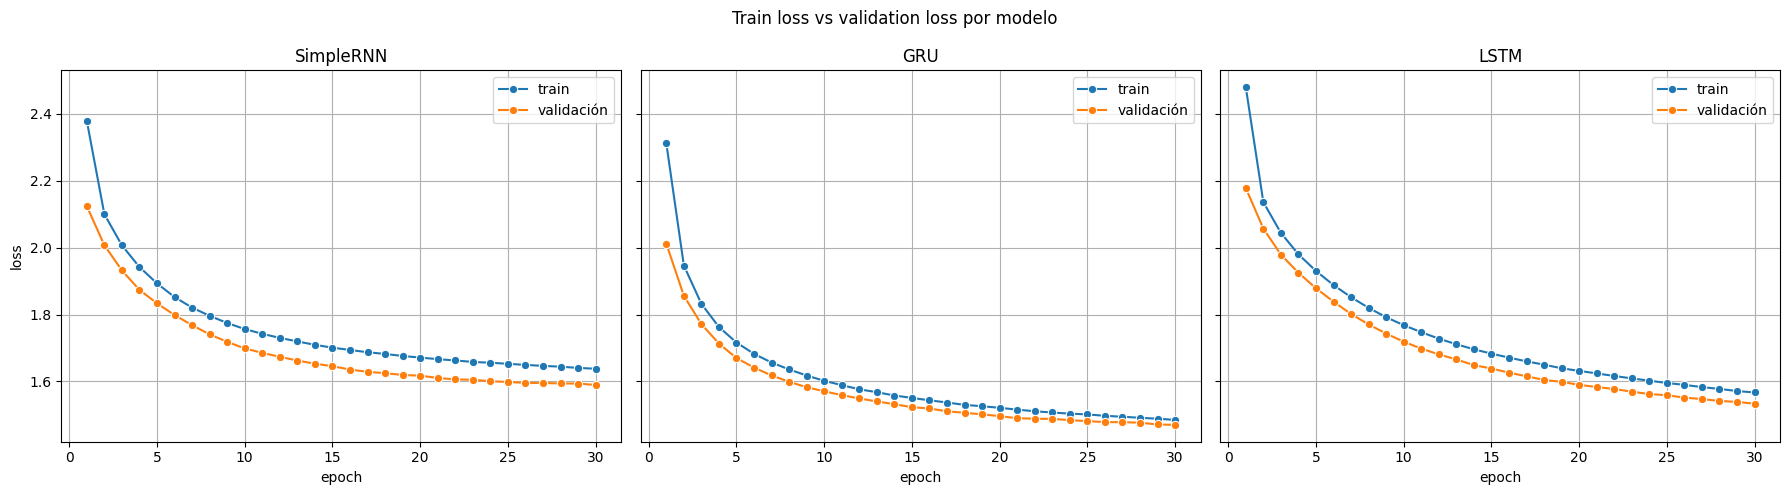

In [105]:
model_order = [model_name for model_name in MODEL_NAMES if model_name in results["modelo"].unique()]
if not model_order:
    model_order = list(results["modelo"].unique())

fig, axes = plt.subplots(1, len(model_order), figsize=(6 * len(model_order), 5), sharey=True)
if len(model_order) == 1:
    axes = [axes]

for ax, model_name in zip(axes, model_order):
    df_model = results[results["modelo"] == model_name]

    sns.lineplot(data=df_model, x="epoch", y="loss", marker="o", label="train", ax=ax)
    sns.lineplot(data=df_model, x="epoch", y="val_loss", marker="o", label="validación", ax=ax)

    ax.set_title(model_name)
    ax.set_xlabel("epoch")
    ax.set_ylabel("loss")
    ax.grid(True)

plt.suptitle("Train loss vs validation loss por modelo")
plt.tight_layout()
plt.show()


### Nice, no overfitteo. El entrenamiento fue optimo en este aspecto.

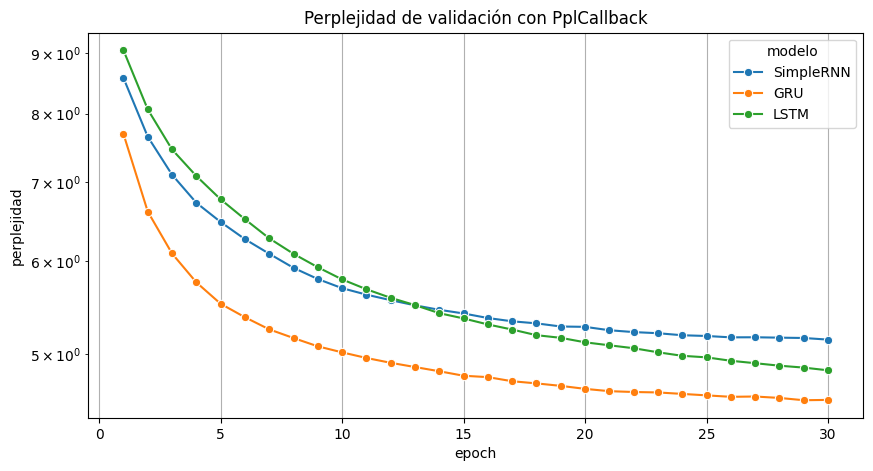

In [91]:
if not ppl_results.empty:
    plt.figure(figsize=(10, 5))
    sns.lineplot(data=ppl_results, x="epoch", y="val_ppl_callback", hue="modelo", marker="o")
    plt.title("Perplejidad de validación con PplCallback")
    plt.xlabel("epoch")
    plt.ylabel("perplejidad")
    plt.yscale("log")
    plt.grid(True)
    plt.show()
else:
    plt.figure(figsize=(10, 5))
    sns.lineplot(data=results, x="epoch", y="val_perplexity", hue="modelo", marker="o")
    plt.title("Perplejidad de validación exp(val_loss)")
    plt.xlabel("epoch")
    plt.ylabel("perplejidad")
    plt.yscale("log")
    plt.grid(True)
    plt.show()



### Predicción del próximo caracter

### Predicción greedy

En cada paso se toma el caracter de mayor probabilidad.


In [92]:
def id_to_char(idx):
    return tok.index_word.get(int(idx), "")


def generate_seq(model, tokenizer, seed_text, max_length, n_words):
    output_text = seed_text.lower()

    for _ in range(n_words):
        encoded = tokenizer.texts_to_sequences([output_text])[0]
        encoded = pad_sequences([encoded], maxlen=max_length, padding="pre", truncating="pre")

        probs = model.predict(encoded, verbose=0)[0]
        probs[0] = 0.0
        y_hat = int(np.argmax(probs))

        out_char = id_to_char(y_hat)
        output_text += out_char

    return output_text

In [93]:
input_text = "oh musa"

greedy_outputs = pd.DataFrame([
    {
        "modelo": model_name,
        "metodo": "greedy",
        "texto": generate_seq(model, tok, input_text, max_length=max_context_size, n_words=300),
    }
    for model_name, model in models.items()
])

greedy_outputs

,modelo,metodo,texto
0,SimpleRNN,greedy,oh musar en la corazón de la corazón de la cor...
1,GRU,greedy,oh musar en la casa de la casa de la casa de l...
2,LSTM,greedy,oh musa de la casa de la casa de la casa de la...


### Beam search determinístico y estocástico

La versión determinística toma los candidatos más probables; la versión estocástica muestrea candidatos usando temperatura.


In [94]:
from scipy.special import softmax


def encode(input_text):
    encoded = tok.texts_to_sequences([input_text.lower()])[0]
    return pad_sequences([encoded], maxlen=max_context_size, padding="pre", truncating="pre")


def decode(tokens):
    return "".join(tok.index_word.get(int(token), "") for token in tokens if int(token) != 0)


# función que selecciona candidatos para el beam search
def select_candidates(pred, num_beams, vocab_size, history_probs, history_tokens, temp=1, sampling=False):

  pred_large = []

  for idx, pp in enumerate(pred):
    log_pp = np.log(np.asarray(pp) + 1e-10)
    log_pp[0] = -1e10
    pred_large.extend(log_pp + history_probs[idx])

  pred_large = np.array(pred_large)

  if sampling:
      temp = max(float(temp), 1e-6)
      idx_select = np.random.choice(
          np.arange(pred_large.shape[0]),
          size=num_beams,
          replace=False,
          p=softmax(pred_large / temp),
      )
  else:
      idx_select = np.argsort(pred_large)[::-1][:num_beams]

  new_history_tokens = np.concatenate((
      np.array(history_tokens)[idx_select // vocab_size],
      np.array([idx_select % vocab_size]).T,
  ), axis=1)

  return pred_large[idx_select.astype(int)], new_history_tokens.astype(int)


def beam_search(model, num_beams, num_words, input, temp=1, sampling=False):
    """Beam search batched: hace una predicción por timestep para todos los beams."""

    # first iteration
    encoded = encode(input)
    y_hat = np.squeeze(model.predict(encoded, verbose=0))
    vocab_size = y_hat.shape[0]

    history_probs = [0.0] * num_beams
    history_tokens = [encoded[0]] * num_beams

    history_probs, history_tokens = select_candidates(
        [y_hat],
        num_beams,
        vocab_size,
        history_probs,
        history_tokens,
        temp=temp,
        sampling=sampling,
    )

    for _ in range(num_words - 1):
      # En vez de llamar predict una vez por beam, armamos un batch con todos los beams.
      input_batch = np.array([hist[-max_context_size:] for hist in history_tokens])
      preds = model.predict(input_batch, verbose=0)

      history_probs, history_tokens = select_candidates(
          preds,
          num_beams,
          vocab_size,
          history_probs,
          history_tokens,
          temp=temp,
          sampling=sampling,
      )

    return history_probs, history_tokens


In [95]:
# Beam search determinístico solo con LSTM
input_text = "oh musa"
lstm_model = models["LSTM"]

scores, salidas = beam_search(
    lstm_model,
    num_beams=5,
    num_words=200,
    input=input_text,
    sampling=False,
)

beam_det_outputs = pd.DataFrame([{
    "modelo": "LSTM",
    "metodo": "beam determinístico",
    "score": scores[0],
    "temperatura": np.nan,
    "texto": decode(salidas[0]),
}])

beam_det_outputs


,modelo,metodo,score,temperatura,texto
0,LSTM,beam determinístico,-104.104691,NaN,oh musa de los pretendientes de los pretendien...


In [ ]:
# Beam search estocástico solo con LSTM y tres temperaturas
temperaturas = [0.5, 1.0, 2.0]
beam_stochastic_outputs = []

for temp in temperaturas:
    scores, salidas = beam_search(
        lstm_model,
        num_beams=5,
        num_words=200,
        input=input_text,
        temp=temp,
        sampling=True,
    )
    beam_stochastic_outputs.append({
        "modelo": "LSTM",
        "metodo": "beam estocástico",
        "temperatura": temp,
        "score": scores[0],
        "texto": decode(salidas[0]),
    })

beam_stochastic_outputs = pd.DataFrame(beam_stochastic_outputs)
beam_stochastic_outputs

,modelo,metodo,temperatura,score,texto
0,LSTM,beam estocástico,0.5,-124.611847,oh musa de los hombres de los compañeros para ...
1,LSTM,beam estocástico,1.0,-156.254578,oh musas los mismos en la bronce de las muchas...
2,LSTM,beam estocástico,2.0,-288.729492,"oh musar. todos, detáronse fuendo á mestores m..."


### Comparación de generación en tablas

Estas tablas quedan como respaldo si Gradio no funciona y también sirven para copiar ejemplos a las conclusiones.


In [ ]:
from IPython.display import display

# Tabla 1: comparación simple de los tres modelos con greedy.
model_generation_comparison = greedy_outputs[["modelo", "metodo", "texto"]].copy()

# Tabla 2: comparación de estrategias con LSTM.
lstm_generation_grid = pd.concat([
    greedy_outputs[greedy_outputs["modelo"] == "LSTM"],
    beam_det_outputs,
    beam_stochastic_outputs,
], ignore_index=True, sort=False)

# Mantengo este nombre para compatibilidad con celdas previas.
generation_comparison = lstm_generation_grid



In [ ]:
print("Comparación de modelos con greedy")
display(model_generation_comparison)

print("Grid de generación con LSTM")
lstm_generation_grid[["modelo", "metodo", "temperatura", "texto"]]

Comparación de modelos con greedy


,modelo,metodo,texto
0,SimpleRNN,greedy,oh musar en la corazón de la corazón de la corazón de la corazón de la corazón de la corazón de la corazón de la corazón de la corazón de la corazón de la corazón de la corazón de la corazón de la corazón de la corazón de la corazón de la corazón de la corazón de la corazón de la corazón de la corazón de l
1,GRU,greedy,oh musar en la casa de la casa de la casa de la casa de la casa de la casa de la casa de la casa de la casa de la casa de la casa de la casa de la casa de la casa de la casa de la casa de la casa de la casa de la casa de la casa de la casa de la casa de la casa de la casa de la casa de la casa de la casa d
2,LSTM,greedy,oh musa de la casa de la casa de la casa de la casa de la casa de la casa de la casa de la casa de la casa de la casa de la casa de la casa de la casa de la casa de la casa de la casa de la casa de la casa de la casa de la casa de la casa de la casa de la casa de la casa de la casa de la casa de la casa de


Grid de generación con LSTM


,modelo,metodo,temperatura,texto
0,LSTM,greedy,NaN,oh musa de la casa de la casa de la casa de la casa de la casa de la casa de la casa de la casa de la casa de la casa de la casa de la casa de la casa de la casa de la casa de la casa de la casa de la casa de la casa de la casa de la casa de la casa de la casa de la casa de la casa de la casa de la casa de
1,LSTM,beam determinístico,NaN,oh musa de los pretendientes de los pretendientes de los pretendientes de los pretendientes de los pretendientes de los pretendientes de los pretendientes de los pretendientes de los pretendientes de los hom
2,LSTM,beam estocástico,0.5,"oh musa de los hombres de los compañeros para los hombres que no se había de la casa de los pretendientes, con el palacio de los pretendientes de los compañeros, como los compañeros de los hombres que se la"
3,LSTM,beam estocástico,1.0,"oh musas los mismos en la bronce de las muchas palabras: yo los dioses, pues los pretendientes, para esclava de los hombres que es el palacio de los compañeros, porque no había de los manos, por el palacio n"
4,LSTM,beam estocástico,2.0,"oh musar. todos, detáronse fuendo á mestores mucho callía no sí aunque descubrió eras cuán destruro para prutente, los hermosres. ya me seguida, el acosa torno del bancio minera! ¿te hubo del noblecho de lag"


### Bueno, acá se ve claramente que el método greedy como es determinista tiene chance de entrar en un ciclo repetitivo. Cuando llega a la frase "de la casa" se queda atascado en esas mismas 3 palabras; es decir,  la palabra más probable luego de la palabra "de", es "la", de "la" es "casa" y de "casa" es "de" de nuevo. "de la corazon" en el caso de la RNN.

### Luego vemos el mismo comportamiento también para el Beam determinístico. El único que zafa es el estocástico. Sin embargo, a T=2 directamente se vuelve un caos sin sentido, un idioma nuevo. A T=1 se mantiene algo de coherencia.

### Comparación final: modelos con beam estocástico

Como el beam estocástico con temperatura media fue el que dio mejores resultados cualitativos, comparamos los tres modelos con esa misma configuración.


In [108]:
# Comparación final de los tres modelos usando beam estocástico con la mayor temperatura probada.
best_temp = 1
model_order = ["SimpleRNN", "GRU", "LSTM"]
beam_high_temp_model_comparison = []

for model_name in model_order:
    scores, salidas = beam_search(
        models[model_name],
        num_beams=5,
        num_words=200,
        input=input_text,
        temp=best_temp,
        sampling=True,
    )
    beam_high_temp_model_comparison.append({
        "modelo": model_name,
        "metodo": "beam estocástico",
        "temperatura": best_temp,
        "score": scores[0],
        "texto": decode(salidas[0]),
    })

beam_high_temp_model_comparison = pd.DataFrame(beam_high_temp_model_comparison)
beam_high_temp_model_comparison[["modelo", "metodo", "temperatura", "texto"]]


,modelo,metodo,temperatura,texto
0,SimpleRNN,beam estocástico,1,"oh musante de la contra de había de los días que se desea seguidas por los compañeros al mano de los martos, que hasta de su hablar de la casa de los días al padre. del manera que había de los compañeros, au"
1,GRU,beam estocástico,1,"oh musaron de los inmortales tierras y para que los pretendientes, en los hombres de la de tu corazón, cuando telémaco de los brillantes ojos. así habló de espléndido que le había que te respondióle el palac"
2,LSTM,beam estocástico,1,"oh musa de los que en su patria, los hombres por el palacio, en la palacio á su precio, y que se llevaron en el palacio, la de la ciudad de los pretendientes me hación de esclava de la telémaco, con el coraz"


### Comparacion final de secuencias generadas con beam estocástico y temperatura 2.0 para los 3 modelos

- SimpleRNN	oh musante de la contra de había de los días que se desea seguidas por los compañeros al mano de los martos, que hasta de su hablar de la casa de los días al padre. del manera que había de los compañeros, au
- GRU	oh musaron de los inmortales tierras y para que los pretendientes, en los hombres de la de tu corazón, cuando telémaco de los brillantes ojos. así habló de espléndido que le había que te respondióle el palac
- LSTM	oh musa: oh musa de los que en su patria, los hombres por el palacio, en la palacio á su precio, y que se llevaron en el palacio, la de la ciudad de los pretendientes me hación de esclava de la telémaco, con el coraz


# Conclusiones

**primera conclusion: la extension de colab en vscode deja que desear, me dio unos lios barbaros**

| Modelo | Parámetros | Mejor val_loss | Mejor perplejidad exp(val_loss) | Mejor perplejidad callback | Val accuracy |
|-----------|------------|----------------|--------------------------------|---------------------------|--------------|
| SimpleRNN | 21.182 | 1.5895 | 4.9012 | 5.1427 | 0.5060 | 
| GRU | 52.798 | 1.4703 | 4.3507 | 4.5683 | 0.5488 | 
| LSTM | 68.030 | 1.5336 | 4.6349 | 4.8433 | 0.5267 | 

A partir de las métricas, GRU fue el mejor modelo global: obtuvo la menor pérdida de validación, la menor perplejidad y la mayor accuracy de validación. SimpleRNN fue el modelo más liviano, pero también el de peor desempeño. LSTM tuvo la mayor cantidad de parámetros, pero en este experimento no superó a GRU.

Las curvas de entrenamiento y validación nos dicen que no overfitteamos gracias a dios. En los tres casos, la pérdida de validación se mantuvo cercana a la pérdida de entrenamiento durante todo el entrenamiento.

En generación, greedy search tendió a caer bucles repetitivos malisimos. Beam search determinístico mejoró parcialmente la búsqueda, pero también caía en un problema similar eventualmente, repetia muchas palabras. Beam search estocástico con temperatura media (1) produjo las salidas más salvables y fue el método cualitativamente más zafable para generar texto. A T=2 ya directamente eran galimatías.

**A nivel cualitativo, dificil evaluar porque la prosa de mi sobrino de 6 años es mejor que lo que generaron estos modelos.**
